### This code provides supports for results in SI section A.6.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [5]:
#input 

state='US'  
fips_dict={'FL':'12','AZ':'4','CA':'6'}
colors={'<20':'#91bfdb','>50': '#fc8d59'}


C:\Users\Linao\AppData\Local\Temp\ipykernel_49104\3995196652.py:60: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


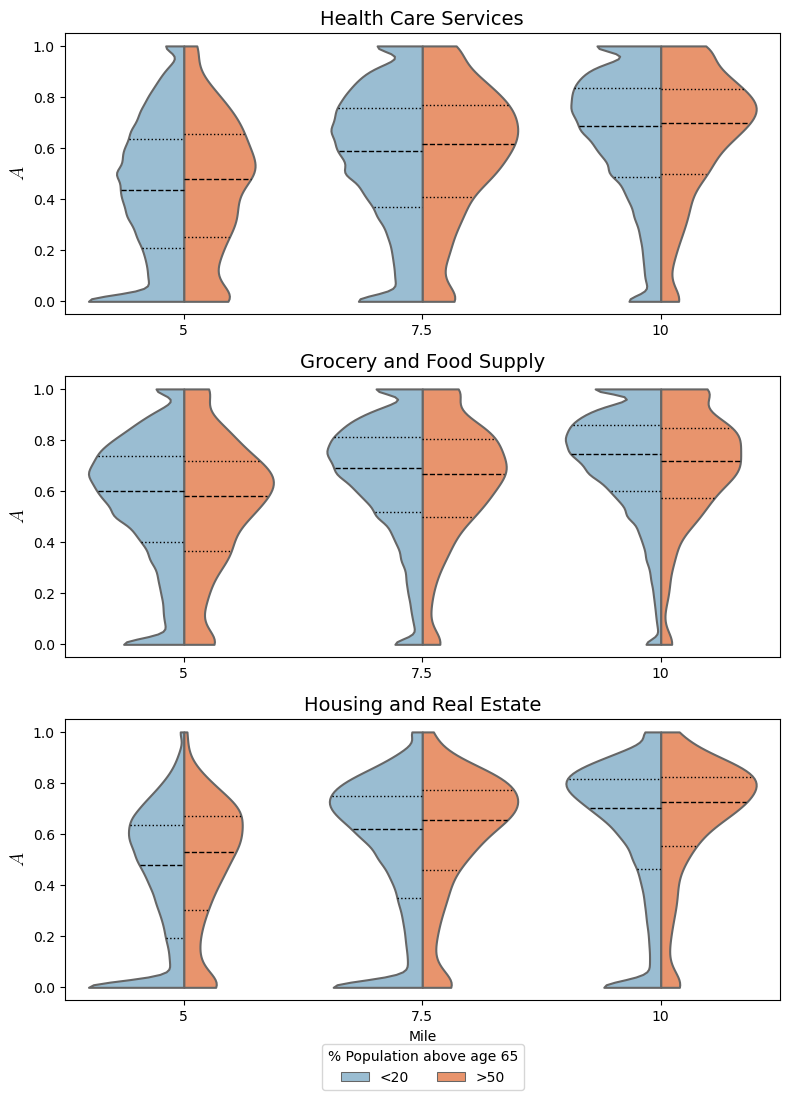

In [11]:

fig, ax=plt.subplots(3,1,constrained_layout=True, figsize=(8, 11))

for i,ptype in enumerate(['Health Care Services','Grocery and Food Supply','Housing and Real Estate']):

### data source: A in 3 mile-type:5 7.5 10 miles
    df=pd.read_csv('data/A under multiple thresholds/'+ptype+'.csv')
### data source: A in 3 mile-type:5 7.5 10 miles


    df=df.drop(columns=['Unnamed: 0'])

    df['census_block_group']=df['census_block_group'].astype(str)
    df['state_fip']=df['state_fip'].astype(str)
    
    if state=='US':
        fiplist=df['state_fip'].unique().tolist()
    else:
        fiplist=[fips_dict[state]]
    
        
    plotdata=df[(df['state_fip'].isin(fiplist))&(df['50%to20%_age']!=0.5)].dropna(subset=["accratio_1"])

    plotdata['50%to20%_age']=plotdata.apply(lambda x: '>50' if x['50%to20%_age']==1 else '<20',axis=1)
    
    idlist=['census_block_group', 'parent_type', 'demand_visits',
       'county_fip', 'state_fip', 'population_by_age', 'percent_above_65',
       'demand_ratios', '50%to20%_age']
    valu_vars=[ 'accratio_1', 'accratio_2.5', 'accratio_5', 'accratio_7.5', 'accratio_10']

    df_melted = plotdata.melt(id_vars=idlist, value_vars=valu_vars,var_name='mile', value_name='accratio')
    df_melted['mile'] =df_melted.apply(lambda x: x['mile'][9:], axis=1 )
    
    sn=sns.violinplot(x='mile',y='accratio',hue='50%to20%_age',hue_order=['<20','>50'],
                      data=df_melted[(df_melted['mile']!='1')&(df_melted['mile']!='2.5')],ax=ax[i],palette=colors,cut=0.0,inner="quartiles",split=True)


    quartile_lines = [line for line in ax[i].lines if line.get_linestyle() == '--']


    for k,line in enumerate(quartile_lines):
        if k%3==1:
            line.set_color('black') 
            line.set_linewidth(1)  
            line.set_linestyle('--')  
        else:
            line.set_color('black')  
            line.set_linewidth(1)  
            line.set_linestyle(':')  
    
    sn.set_title(ptype,fontsize=14)
    
    sn.set_ylabel(r'$A$', fontsize=14, usetex=True)
    if i<2:
        sn.legend('',edgecolor='white')
        sn.set_xlabel('')
    else:
        sn.legend(title='% Population above age 65',ncol=2,loc=(0.36,-0.32))
        sn.set_xlabel('Mile')
    ax[i].tick_params(axis='both', which='both', bottom=True, left=True) 
fig.tight_layout()

    

In [12]:
#save figure
#fig.savefig(r'..\..\..\R1\accratios_all_miles_US\SI_US_distri_A_3_dis.png',dpi=300)
prepath='D:/main/1_research/P10_Mobility/p10_aging mobility/figures_colorblind_safe/SI/'
fig.savefig(prepath+'SI_US_distri_A_3_dis.png',dpi=600)  